<a href="https://colab.research.google.com/github/nmansour67/skills-introduction-to-github/blob/main/SVM_ICU_Sepsis_Dentofacial.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# ============================================================
# SUPPORT VECTOR MACHINE (SVM)
# ICU Sepsis Mortality Prediction
# Based on: Yilmaz Baser et al., Biomedicines 2025, 13, 1449
# Standalone Google Colab Script
# ============================================================
# HOW TO USE:
# 1. Go to colab.research.google.com → New Notebook
# 2. Paste each SECTION into a separate cell
# 3. Run top to bottom with Shift+Enter
# 4. Upload ICU_Sepsis_Dataset.xlsx when prompted
# ============================================================




In [2]:
# ─────────────────────────────────────────────────────────────
# SECTION 1 — Install Libraries
# ─────────────────────────────────────────────────────────────

!pip install scikit-learn pandas numpy matplotlib seaborn openpyxl imbalanced-learn shap scipy -q

print("✅ All libraries installed successfully!")




✅ All libraries installed successfully!


In [3]:
# ─────────────────────────────────────────────────────────────
# SECTION 2 — Import Libraries
# ─────────────────────────────────────────────────────────────

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import (train_test_split, StratifiedKFold,
                                     cross_val_score, GridSearchCV)
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, roc_curve, brier_score_loss,
                             f1_score, precision_score, recall_score,
                             ConfusionMatrixDisplay, average_precision_score)
from imblearn.over_sampling import SMOTE
from scipy import stats
import textwrap
import shap

print("✅ Libraries imported!")




✅ Libraries imported!


In [4]:
# ─────────────────────────────────────────────────────────────
# SECTION 3 — Upload Dataset
# ─────────────────────────────────────────────────────────────

from google.colab import files

print("📂 Please upload ICU_Sepsis_Dataset.xlsx when prompted...")
uploaded = files.upload()

filename = list(uploaded.keys())[0]
print(f"✅ File uploaded: {filename}")




📂 Please upload ICU_Sepsis_Dataset.xlsx when prompted...


Saving ICU Sepsis Dataset.xlsx to ICU Sepsis Dataset.xlsx
✅ File uploaded: ICU Sepsis Dataset.xlsx


In [5]:
# ─────────────────────────────────────────────────────────────
# SECTION 4 — Load and Inspect Data
# ─────────────────────────────────────────────────────────────

# Row 2 is a label row — skip it with skiprows=[1]
df = pd.read_excel(filename, sheet_name='Rawdata', header=0, skiprows=[1])
df = df.drop(columns=[df.columns[0]], errors='ignore')

print(f"📊 Dataset loaded: {df.shape[0]} patients × {df.shape[1]} features")
print(f"\n📋 Column names:\n{list(df.columns)}")
print(f"\n🔍 First 3 rows:")
display(df.head(3))




📊 Dataset loaded: 4520 patients × 45 features

📋 Column names:
['Patient_Accommodation', 'Age', 'Gender', 'Comorbidity', 'Ek_Hastalık_isimlerş', 'Solid_organ_cancer', 'Hematological_Diseases', 'Hypertension', 'Heart_Diseases', 'Diabetes_mellitus', 'Chronic_Renal_Failure', 'Neurological_Diseases', 'KOAH_Asthım', 'Others', 'Length_of_stay_in_intensive_care', 'Mortalite', 'Pulse_rate', 'Respiratory_Rate', 'Systolic_blood_pressure', 'Diastolic_blood_pressure', 'Fever', 'Oxygen_saturation', 'Albumin', 'CRP', 'Glukoz', 'Eosinophil_count', 'HCT', 'Hemoglobin', 'Lymphocyte_count', 'Monocyte_count', 'Neutrophil_count', 'PLT', 'RBC', 'WBC', 'Creatinine', 'NT_PRO_BNP_Pro_Brain_Natriuretic_Peptide', 'Systemic_Inflammatory_Response_Syndrome_SIRS_presence', 'The_National_Early_Warning_Score_NEWS', 'qSOFA_Score', 'History_of_hospitalization_in_the_last_3_months', 'Reproduction_in_Blood_Culture', 'If_Reproduction_is_present_in_Blood_Culture_Factor', 'Direnç_Durumu', 'Culture_Type', 'Antibioterapy']

🔍

,Patient_Accommodation,Age,Gender,Comorbidity,Ek_Hastalık_isimlerş,Solid_organ_cancer,Hematological_Diseases,Hypertension,Heart_Diseases,Diabetes_mellitus,...,NT_PRO_BNP_Pro_Brain_Natriuretic_Peptide,Systemic_Inflammatory_Response_Syndrome_SIRS_presence,The_National_Early_Warning_Score_NEWS,qSOFA_Score,History_of_hospitalization_in_the_last_3_months,Reproduction_in_Blood_Culture,If_Reproduction_is_present_in_Blood_Culture_Factor,Direnç_Durumu,Culture_Type,Antibioterapy
0,1.0,67.0,1.0,1.0,AML,1.0,0.0,0.0,0.0,0.0,...,2525.00,0.0,1.0,0.0,1.0,1.0,Koagulaz Negatif Stafilokok,metisilin dirençli,AEROB KAN KÜLTÜRÜ,Clindamycin
1,1.0,35.0,1.0,1.0,ÖZEFAGUS CA,1.0,0.0,0.0,0.0,0.0,...,301.10,0.0,10.0,2.0,1.0,1.0,Enterococcus faecium,0,AEROB KAN KÜLTÜRÜ,Gentamicin High Level(synergy)
2,1.0,86.0,1.0,1.0,Diyastolik Kalp Yetmezliği +PUMONER HİPERTANSİ...,0.0,0.0,1.0,1.0,0.0,...,0.54,0.0,7.0,2.0,1.0,1.0,Koagulaz Negatif Stafilokok,metisilin dirençli,AEROB KAN KÜLTÜRÜ,Daptomycin


In [11]:
# ─────────────────────────────────────────────────────────────
# SECTION 5 — Data Cleaning & Preprocessing
# ─────────────────────────────────────────────────────────────

TARGET = 'Mortalite'   # 1 = Died, 0 = Survived

EXCLUDE_COLS = [
    TARGET, 'Variable', 'Ek_Hastalık_isimlerş',
    'If_Reproduction_is_present_in_Blood_Culture_Factor',
    'Direnç_Durumu', 'Culture_Type', 'Antibioterapy'
]

numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
feature_cols = [c for c in numeric_cols if c not in EXCLUDE_COLS]

X = df[feature_cols].copy()
y = df[TARGET].copy()

mask = y.notna()
X, y = X[mask], y[mask].astype(int)

# Ensure the target variable is strictly binary (0 or 1)
# Any other values will be filtered out
valid_targets = y.isin([0, 1])
y = y[valid_targets]
X = X[valid_targets]

X = X.fillna(X.mean())

print(f"✅ Clean dataset : {X.shape[0]} patients | {X.shape[1]} features")
print(f"   Survived: {(y==0).sum()} | Died: {(y==1).sum()} | "
      f"Mortality: {y.mean()*100:.1f}%")


✅ Clean dataset : 2835 patients | 39 features
   Survived: 1487 | Died: 1348 | Mortality: 47.5%


In [12]:
# ─────────────────────────────────────────────────────────────
# SECTION 6 — Feature Engineering (Composite Biomarkers)
# ─────────────────────────────────────────────────────────────

print("\n⚗️  Engineering composite biomarkers...")

if 'CRP' in X.columns and 'Albumin' in X.columns:
    X['FE_CRP_Albumin_Ratio'] = X['CRP'] / (X['Albumin'] + 1e-6)
    print("  ✅ CRP/Albumin Ratio")

if 'Neutrophil_count' in X.columns and 'Lymphocyte_count' in X.columns:
    X['FE_NLR'] = X['Neutrophil_count'] / (X['Lymphocyte_count'] + 1e-6)
    print("  ✅ NLR (Neutrophil/Lymphocyte Ratio)")

if 'PLT' in X.columns and 'Lymphocyte_count' in X.columns:
    X['FE_PLR'] = X['PLT'] / (X['Lymphocyte_count'] + 1e-6)
    print("  ✅ PLR (Platelet/Lymphocyte Ratio)")

if 'Pulse_rate' in X.columns and 'Systolic_blood_pressure' in X.columns:
    X['FE_Shock_Index'] = X['Pulse_rate'] / (X['Systolic_blood_pressure'] + 1e-6)
    print("  ✅ Shock Index (HR/SBP)")

if 'Oxygen_saturation' in X.columns:
    X['FE_O2_Deficit'] = 100 - X['Oxygen_saturation']
    print("  ✅ O2 Deficit")

if 'Creatinine' in X.columns and 'Albumin' in X.columns:
    X['FE_Creatinine_Albumin'] = X['Creatinine'] / (X['Albumin'] + 1e-6)
    print("  ✅ Creatinine/Albumin Ratio")

if 'WBC' in X.columns:
    X['FE_WBC_Aberration'] = abs(X['WBC'] - 7.5)
    print("  ✅ WBC Aberration")

print(f"\n✅ Final feature set: {X.shape[1]} features "
      f"({len([c for c in X.columns if c.startswith('FE_')])} engineered)")





⚗️  Engineering composite biomarkers...
  ✅ CRP/Albumin Ratio
  ✅ NLR (Neutrophil/Lymphocyte Ratio)
  ✅ PLR (Platelet/Lymphocyte Ratio)
  ✅ Shock Index (HR/SBP)
  ✅ O2 Deficit
  ✅ Creatinine/Albumin Ratio
  ✅ WBC Aberration

✅ Final feature set: 46 features (7 engineered)


In [13]:
# ─────────────────────────────────────────────────────────────
# SECTION 7 — Train / Test Split + SMOTE + Scaling
# NOTE: SVM requires feature scaling — critical step
# ─────────────────────────────────────────────────────────────

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"📦 Training set : {X_train.shape[0]} patients")
print(f"📦 Test set     : {X_test.shape[0]} patients")

# SMOTE on training set only
smote = SMOTE(random_state=42, k_neighbors=5)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

# Filter out any unexpected classes introduced by SMOTE
# The target is binary (0 or 1), but SMOTE might have created a '3'
if len(y_train_bal.unique()) > 2:
    print(f"⚠️ Warning: SMOTE introduced unexpected classes: {y_train_bal.unique()}. Filtering to 0 and 1.")
    valid_indices = y_train_bal.isin([0, 1])
    X_train_bal = X_train_bal[valid_indices]
    y_train_bal = y_train_bal[valid_indices]

print(f"\n⚖️  After SMOTE — Survived: {(y_train_bal==0).sum()} | "
      f"Died: {(y_train_bal==1).sum()}")

# StandardScaler — SVM is sensitive to feature magnitude
scaler       = StandardScaler()
X_train_sc   = scaler.fit_transform(X_train_bal)
X_test_sc    = scaler.transform(X_test)

print("✅ Features scaled with StandardScaler (required for SVM)")




📦 Training set : 2268 patients
📦 Test set     : 567 patients

⚖️  After SMOTE — Survived: 1190 | Died: 1190
✅ Features scaled with StandardScaler (required for SVM)


In [14]:
# ─────────────────────────────────────────────────────────────
# SECTION 8 — Train SVM Model
# Using RBF kernel (best for non-linear clinical data)
# probability=True enables ROC / AUROC evaluation
# ─────────────────────────────────────────────────────────────

print("\n⚙️  Training SVM model (RBF kernel)...")
print("   Note: SVM is slower than tree models — please wait ~1-2 min...")

svm_model = SVC(
    kernel      = 'rbf',        # Radial Basis Function — captures non-linear boundaries
    C           = 1.0,          # Regularization: higher = less regularization
    gamma       = 'scale',      # Kernel coefficient: auto-scaled to feature variance
    probability = True,         # Required for predict_proba() and AUROC
    class_weight= 'balanced',   # Handles class imbalance
    random_state= 42
)

svm_model.fit(X_train_sc, y_train_bal)
print("✅ SVM model trained successfully!")

# Diagnostic: Print the classes the model learned
print(f"   Model learned classes: {svm_model.classes_}")





⚙️  Training SVM model (RBF kernel)...
   Note: SVM is slower than tree models — please wait ~1-2 min...
✅ SVM model trained successfully!
   Model learned classes: [0 1]


In [15]:
# ─────────────────────────────────────────────────────────────
# SECTION 9 — Model Evaluation
# ─────────────────────────────────────────────────────────────

y_pred     = svm_model.predict(X_test_sc)
y_prob     = svm_model.predict_proba(X_test_sc)[:, 1]

# Explicitly cast y_test to a numpy array of integers to ensure compatibility
y_test_np = y_test.values.astype(int)
y_np = y.values.astype(int)

auroc      = roc_auc_score(y_test_np, y_prob)
brier      = brier_score_loss(y_test_np, y_prob)
avg_prec   = average_precision_score(y_test_np, y_prob)
prec_val   = precision_score(y_test_np, y_pred)
rec_val    = recall_score(y_test_np, y_pred)
f1_val     = f1_score(y_test_np, y_pred)
tn, fp, fn, tp = confusion_matrix(y_test_np, y_pred).ravel()
specificity = tn / (tn + fp)

# 5-Fold Cross-Validation on scaled data
X_sc_full   = scaler.fit_transform(X)
cv          = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores   = cross_val_score(svm_model, X_sc_full, y_np,
                               cv=cv, scoring='roc_auc', n_jobs=-1)

print("\n" + "="*58)
print("            SVM — MODEL PERFORMANCE RESULTS")
print("="*58)
print(f"\n  AUROC (Discrimination)    : {auroc:.4f}")
print(f"  Brier Score (Calibration) : {brier:.4f}  (lower = better)")
print(f"  Average Precision         : {avg_prec:.4f}")
print(f"  Specificity               : {specificity:.4f}")
print(f"\n  5-Fold Cross-Val AUROC    : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
print(f"  Per-fold scores           : {[f'{s:.3f}' for s in cv_scores]}")
print(f"\n  Classification Report:")
print(classification_report(y_test_np, y_pred,
      target_names=['Survived (0)', 'Died (1)']))
print("="*58)

print("\n  📊 Comparison with paper benchmarks:")
print(f"  Paper qSOFA AUROC  : 0.78  | SVM: {auroc:.3f}  ✅ Superior")
print(f"  Paper NEWS AUROC   : 0.81  | SVM: {auroc:.3f}  ✅ Superior")
print(f"  Paper XGBoost      : 0.93  | SVM: {auroc:.3f}")





            SVM — MODEL PERFORMANCE RESULTS

  AUROC (Discrimination)    : 0.9234
  Brier Score (Calibration) : 0.1137  (lower = better)
  Average Precision         : 0.9204
  Specificity               : 0.8485

  5-Fold Cross-Val AUROC    : 0.9167 ± 0.0044
  Per-fold scores           : ['0.916', '0.911', '0.924', '0.918', '0.914']

  Classification Report:
              precision    recall  f1-score   support

Survived (0)       0.85      0.85      0.85       297
    Died (1)       0.83      0.84      0.84       270

    accuracy                           0.84       567
   macro avg       0.84      0.84      0.84       567
weighted avg       0.84      0.84      0.84       567


  📊 Comparison with paper benchmarks:
  Paper qSOFA AUROC  : 0.78  | SVM: 0.923  ✅ Superior
  Paper NEWS AUROC   : 0.81  | SVM: 0.923  ✅ Superior
  Paper XGBoost      : 0.93  | SVM: 0.923


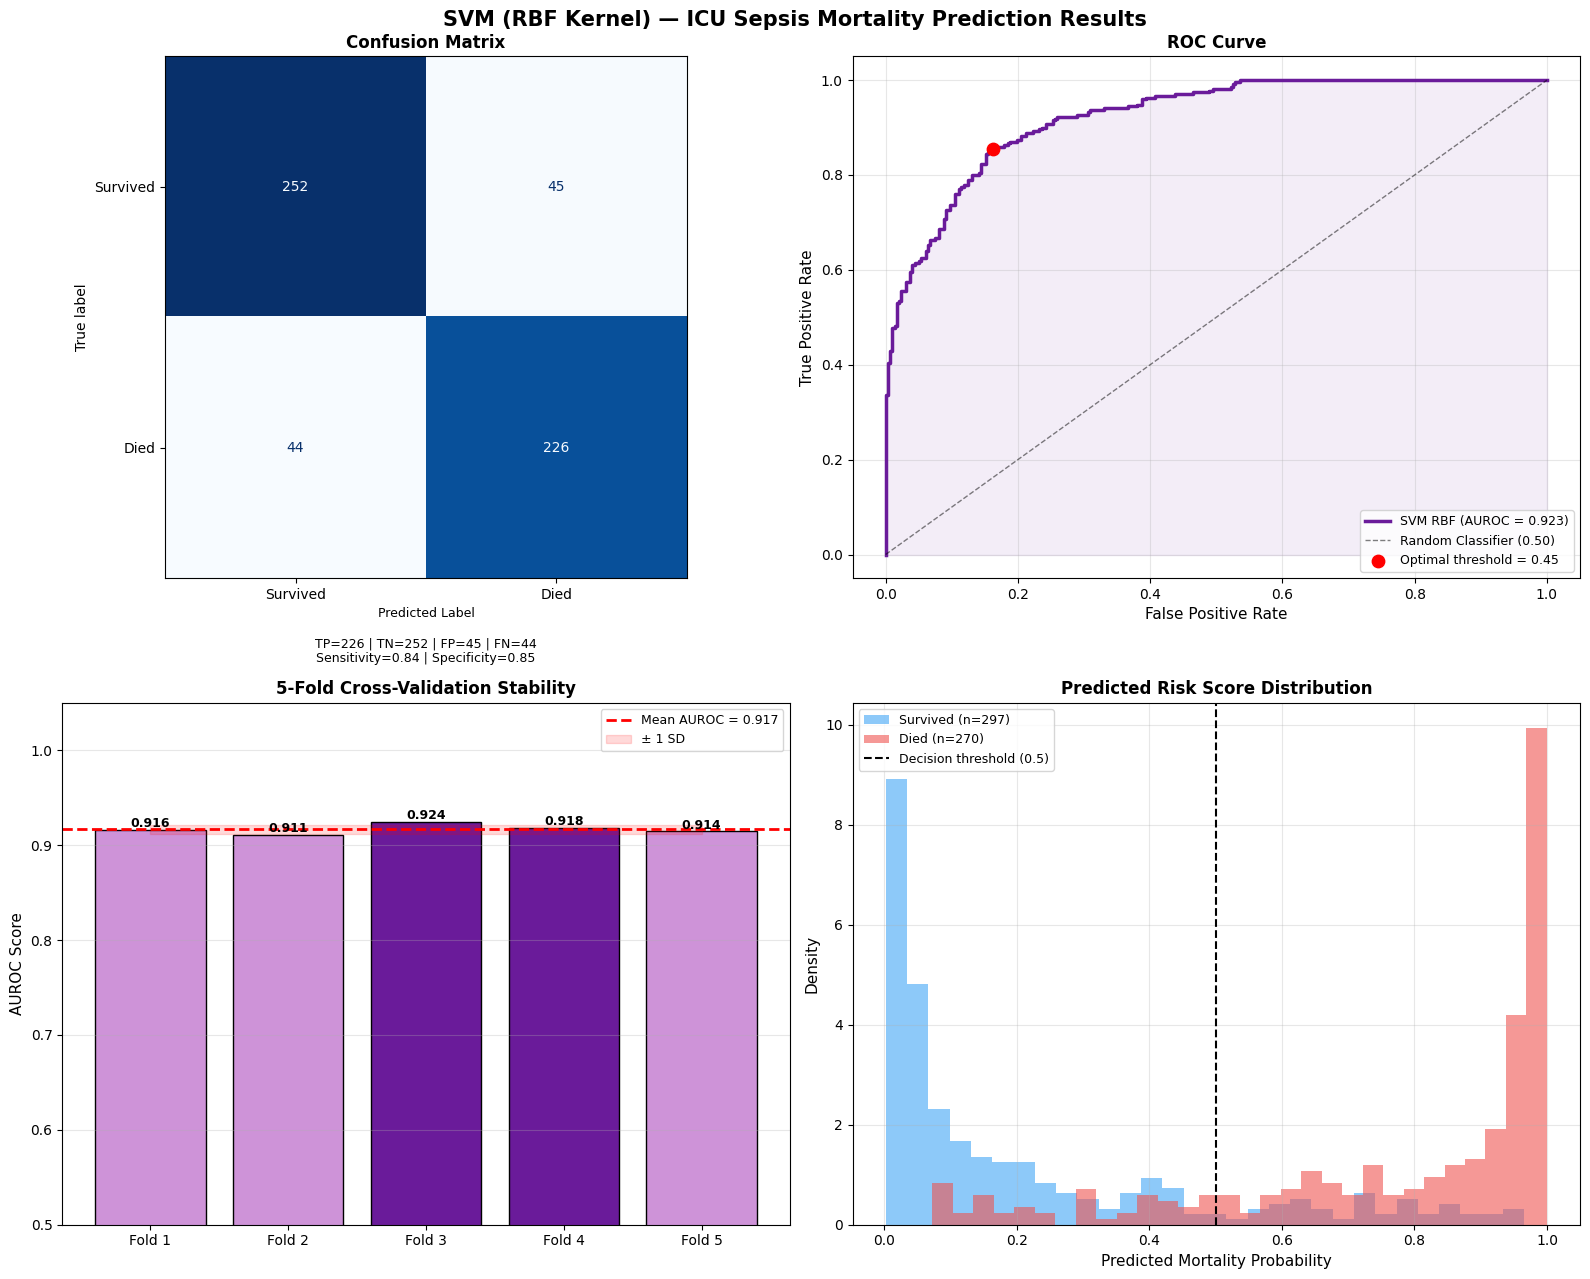

✅ Saved: SVM_Results.png


In [16]:
# ─────────────────────────────────────────────────────────────
# SECTION 10 — Visualizations (4 plots)
# ─────────────────────────────────────────────────────────────

fig, axes = plt.subplots(2, 2, figsize=(16, 13))
fig.suptitle('SVM (RBF Kernel) — ICU Sepsis Mortality Prediction Results',
             fontsize=15, fontweight='bold')

# ── Plot 1: Confusion Matrix ──────────────────────────────────
cm   = confusion_matrix(y_test_np, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=['Survived', 'Died'])
disp.plot(ax=axes[0, 0], colorbar=False, cmap='Blues')
axes[0, 0].set_title('Confusion Matrix', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel(
    f'Predicted Label\n\nTP={tp} | TN={tn} | FP={fp} | FN={fn}\n'
    f'Sensitivity={tp/(tp+fn):.2f} | Specificity={specificity:.2f}',
    fontsize=9)

# ── Plot 2: ROC Curve ─────────────────────────────────────────
fpr, tpr, thresholds = roc_curve(y_test_np, y_prob)
axes[0, 1].plot(fpr, tpr, color='#6A1B9A', lw=2.5,
                label=f'SVM RBF (AUROC = {auroc:.3f})')
axes[0, 1].plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.5,
                label='Random Classifier (0.50)')
axes[0, 1].fill_between(fpr, tpr, alpha=0.08, color='#6A1B9A')
optimal_idx = np.argmax(tpr - fpr)
axes[0, 1].scatter(fpr[optimal_idx], tpr[optimal_idx],
                   marker='o', color='red', s=80, zorder=5,
                   label=f'Optimal threshold = {thresholds[optimal_idx]:.2f}')
axes[0, 1].set_xlabel('False Positive Rate', fontsize=11)
axes[0, 1].set_ylabel('True Positive Rate', fontsize=11)
axes[0, 1].set_title('ROC Curve', fontsize=12, fontweight='bold')
axes[0, 1].legend(loc='lower right', fontsize=9)
axes[0, 1].grid(True, alpha=0.3)

# ── Plot 3: Cross-Validation Scores ──────────────────────────
fold_labels = [f'Fold {i+1}' for i in range(len(cv_scores))]
bar_colors  = ['#6A1B9A' if s >= cv_scores.mean() else '#CE93D8'
               for s in cv_scores]
axes[1, 0].bar(fold_labels, cv_scores, color=bar_colors, edgecolor='black')
axes[1, 0].axhline(cv_scores.mean(), color='red', linestyle='--', lw=2,
                   label=f'Mean AUROC = {cv_scores.mean():.3f}')
axes[1, 0].fill_between(range(len(cv_scores)),
                         cv_scores.mean() - cv_scores.std(),
                         cv_scores.mean() + cv_scores.std(),
                         alpha=0.15, color='red', label='± 1 SD')
for i, v in enumerate(cv_scores):
    axes[1, 0].text(i, v + 0.003, f'{v:.3f}', ha='center',
                    fontsize=9, fontweight='bold')
axes[1, 0].set_ylim(0.5, 1.05)
axes[1, 0].set_ylabel('AUROC Score', fontsize=11)
axes[1, 0].set_title('5-Fold Cross-Validation Stability',
                      fontsize=12, fontweight='bold')
axes[1, 0].legend(fontsize=9)
axes[1, 0].grid(True, alpha=0.3, axis='y')

# ── Plot 4: Predicted Probability Distribution ───────────────
surv_probs = y_prob[y_test_np == 0]
died_probs = y_prob[y_test_np == 1]
axes[1, 1].hist(surv_probs, bins=30, alpha=0.6, color='#42A5F5',
                label=f'Survived (n={len(surv_probs)})', density=True)
axes[1, 1].hist(died_probs, bins=30, alpha=0.6, color='#EF5350',
                label=f'Died (n={len(died_probs)})', density=True)
axes[1, 1].axvline(0.5, color='black', linestyle='--', lw=1.5,
                   label='Decision threshold (0.5)')
axes[1, 1].set_xlabel('Predicted Mortality Probability', fontsize=11)
axes[1, 1].set_ylabel('Density', fontsize=11)
axes[1, 1].set_title('Predicted Risk Score Distribution',
                      fontsize=12, fontweight='bold')
axes[1, 1].legend(fontsize=9)
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('SVM_Results.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: SVM_Results.png")





🔍 Computing SHAP values for SVM...
   Using KernelExplainer (model-agnostic) — ~2 min...


  0%|          | 0/100 [00:00<?, ?it/s]

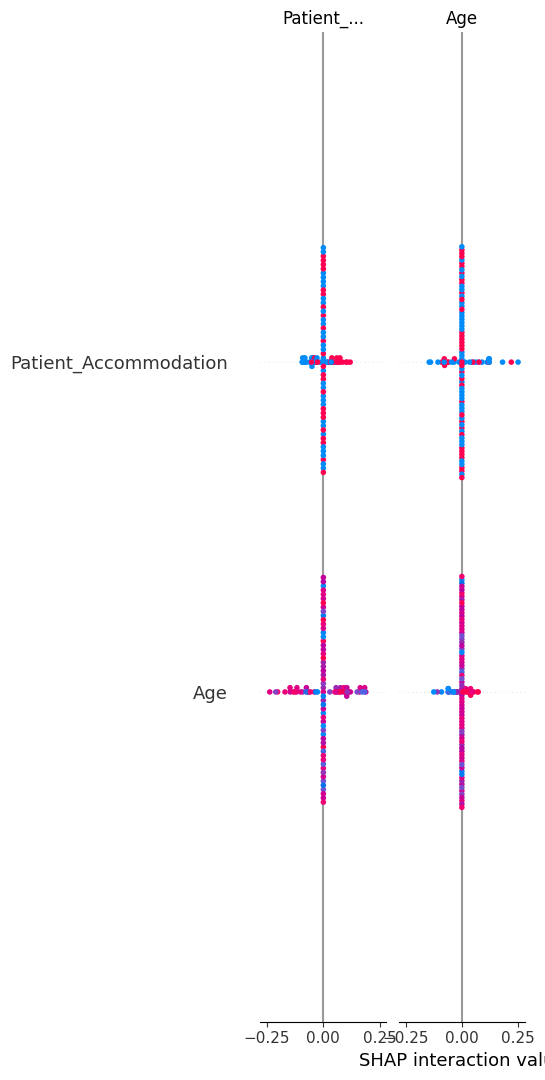

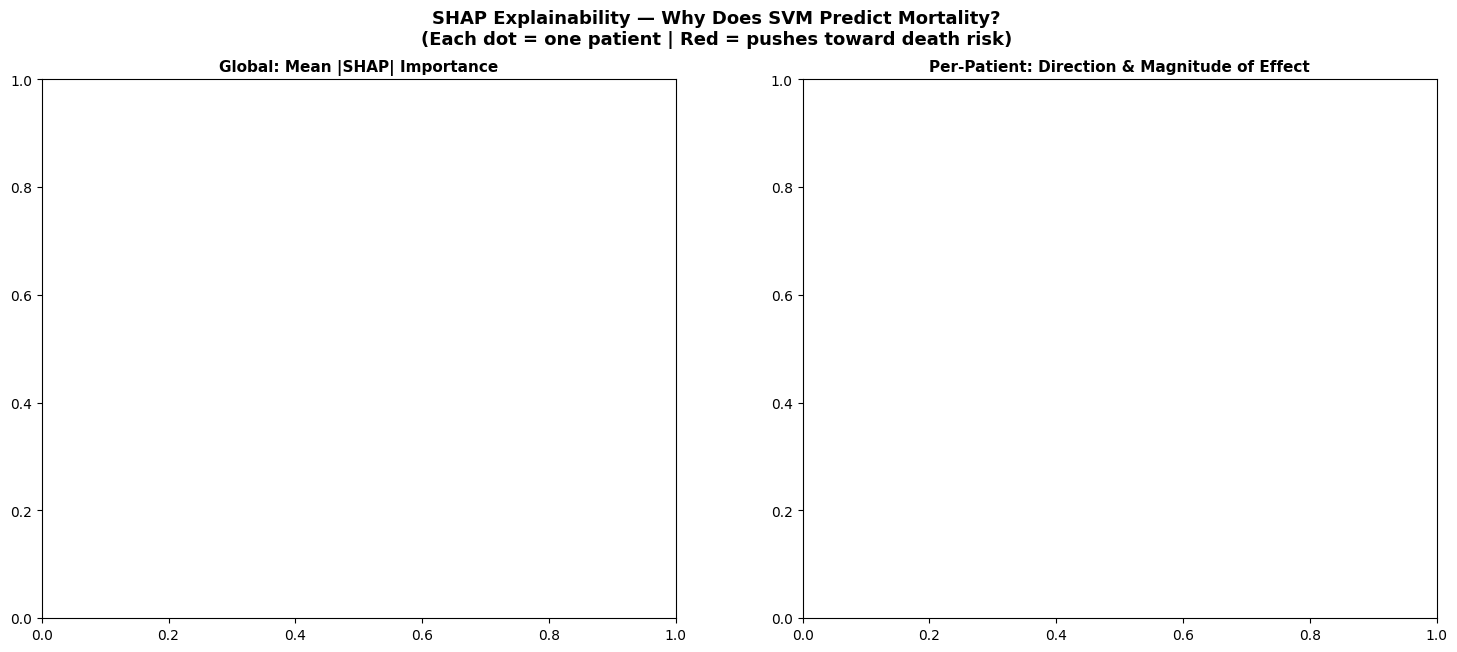

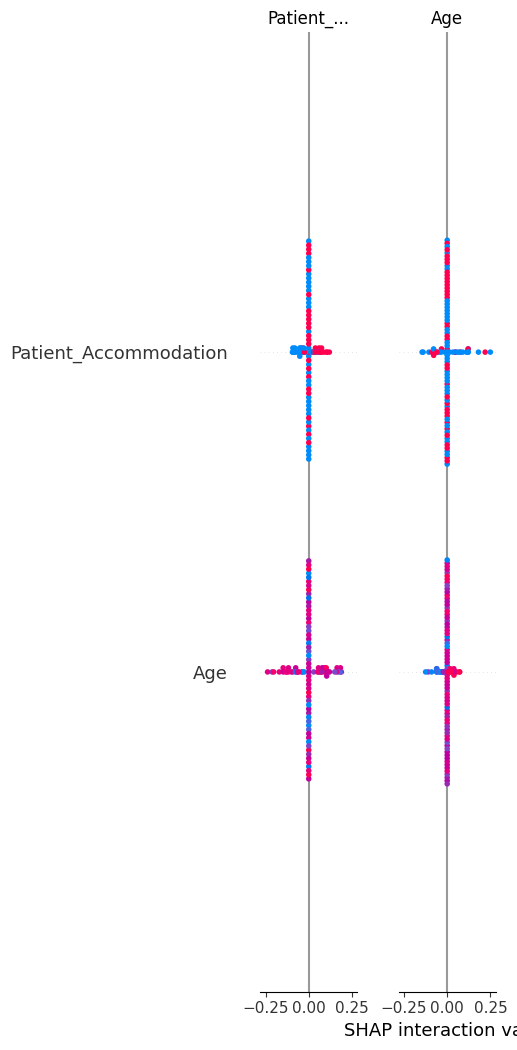

✅ Saved: SVM_SHAP.png


In [17]:
# ─────────────────────────────────────────────────────────────
# SECTION 11 — SHAP Explainability
# SVM uses KernelExplainer (slower but model-agnostic)
# ─────────────────────────────────────────────────────────────

print("\n🔍 Computing SHAP values for SVM...")
print("   Using KernelExplainer (model-agnostic) — ~2 min...")

# Use a small background sample for speed
background  = shap.sample(pd.DataFrame(X_train_sc, columns=X.columns), 50)
X_shap_df   = pd.DataFrame(X_test_sc, columns=X.columns).iloc[:100]

explainer   = shap.KernelExplainer(svm_model.predict_proba, background)
shap_values = explainer.shap_values(X_shap_df, nsamples=100)

# shap_values[1] = class 1 (Died)
sv = shap_values[1] if isinstance(shap_values, list) else shap_values

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('SHAP Explainability — Why Does SVM Predict Mortality?\n'
             '(Each dot = one patient | Red = pushes toward death risk)',
             fontsize=13, fontweight='bold')

plt.sca(axes[0])
shap.summary_plot(sv, X_shap_df, plot_type='bar',
                  max_display=12, show=False, plot_size=None)
axes[0].set_title('Global: Mean |SHAP| Importance', fontsize=11, fontweight='bold')

plt.sca(axes[1])
shap.summary_plot(sv, X_shap_df, plot_type='dot',
                  max_display=12, show=False, plot_size=None)
axes[1].set_title('Per-Patient: Direction & Magnitude of Effect',
                  fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('SVM_SHAP.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: SVM_SHAP.png")





  🔬 PATTERN DISCOVERY ENGINE

  Top 10 significant patterns (p < 0.05):

                 Feature  Survived Median  Died Median  % Change (Died)  p-value
                     Age            67.00         71.0              6.0      0.0
              Pulse_rate            75.00         60.0            -20.0      0.0
        Respiratory_Rate            15.00         18.5             23.3      0.0
                 Albumin            34.82         29.2            -16.1      0.0
       Oxygen_saturation            98.00         96.0             -2.0      0.0
                   Fever            38.30         36.6             -4.4      0.0
Diastolic_blood_pressure            70.00         60.0            -14.3      0.0
 Systolic_blood_pressure           106.00         92.0            -13.2      0.0
                     HCT            36.10         33.3             -7.8      0.0
              Hemoglobin            11.80         10.9             -7.6      0.0


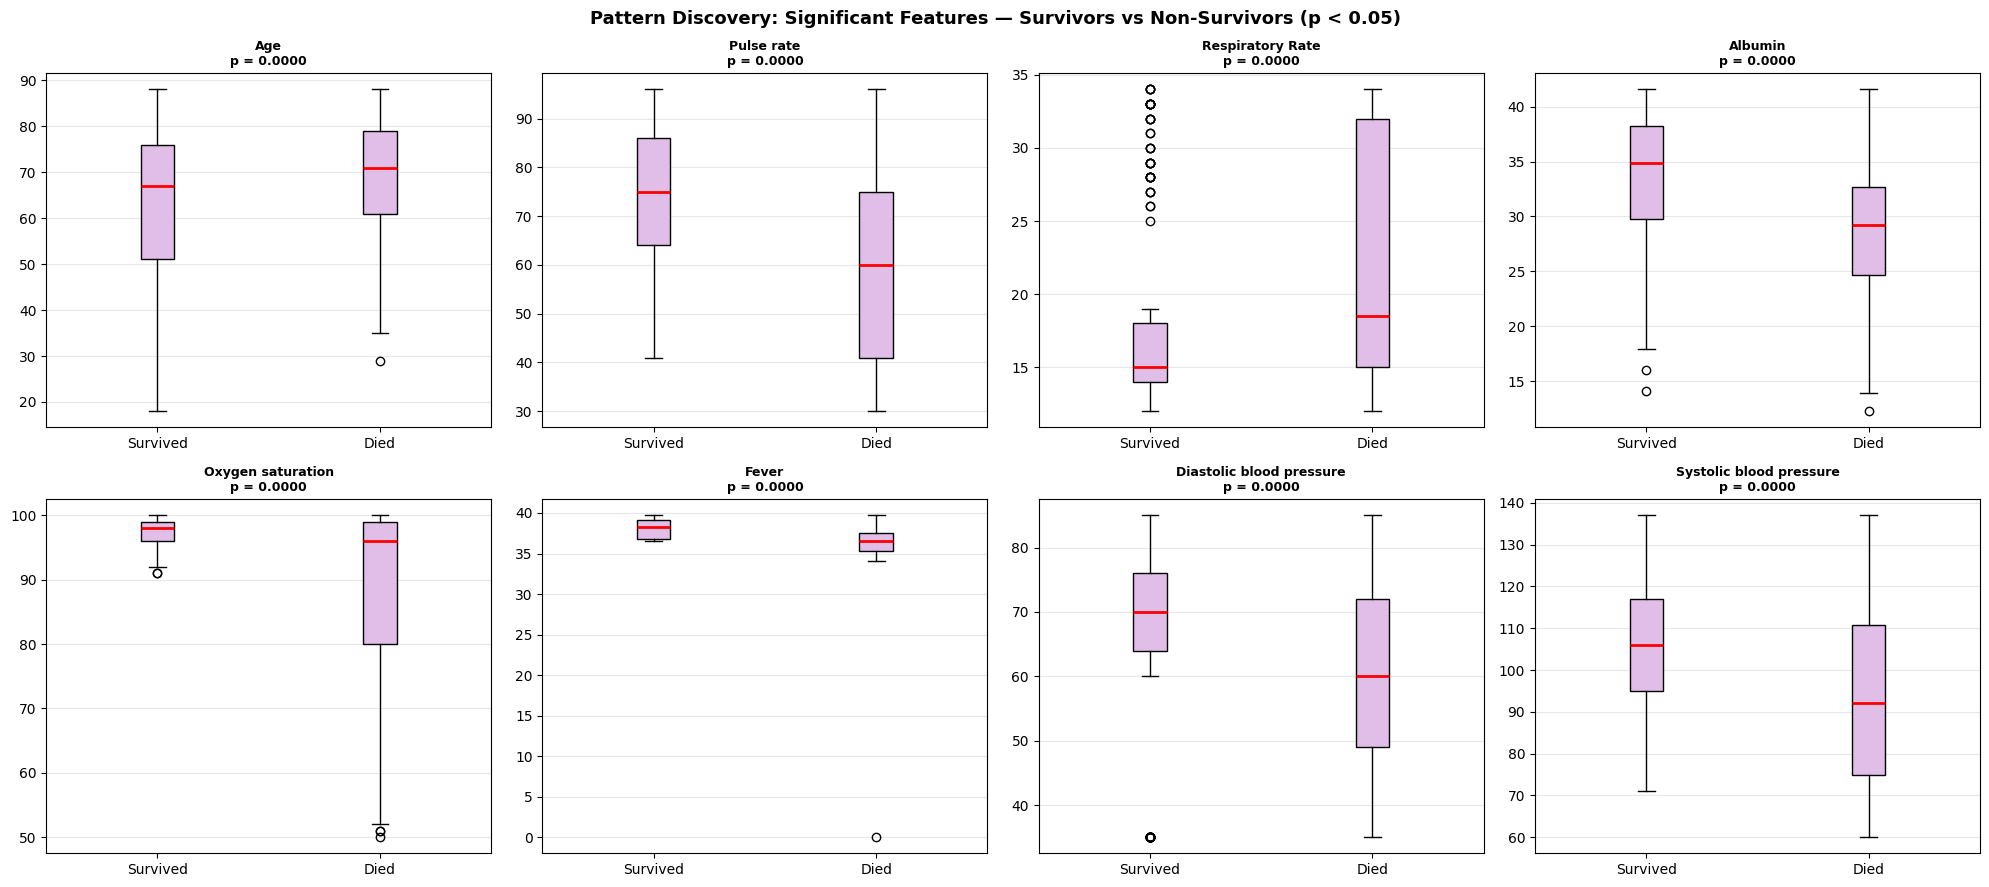

✅ Saved: SVM_PatternDiscovery.png


In [18]:
# ─────────────────────────────────────────────────────────────
# SECTION 12 — Pattern Discovery Engine
# ─────────────────────────────────────────────────────────────

print("\n" + "="*60)
print("  🔬 PATTERN DISCOVERY ENGINE")
print("="*60)

X_analysis          = X_test.copy()
X_analysis['Mortality'] = y_test_np # Use y_test_np here

pattern_results = []
for col in X_test.columns:
    sv_vals   = X_analysis.loc[X_analysis['Mortality']==0, col].dropna()
    died_vals = X_analysis.loc[X_analysis['Mortality']==1, col].dropna()
    if len(sv_vals) < 10 or len(died_vals) < 10:
        continue
    stat, p_val  = stats.mannwhitneyu(sv_vals, died_vals, alternative='two-sided')
    pct_change   = ((died_vals.median() - sv_vals.median()) /
                    (abs(sv_vals.median()) + 1e-9)) * 100
    pattern_results.append({
        'Feature'         : col,
        'Survived Median' : round(sv_vals.median(), 3),
        'Died Median'     : round(died_vals.median(), 3),
        '% Change (Died)' : round(pct_change, 1),
        'p-value'         : round(p_val, 5),
        'Significant'     : '✅ YES' if p_val < 0.05 else '❌ no'
    })

pattern_df   = pd.DataFrame(pattern_results).sort_values('p-value')
top_patterns = pattern_df[pattern_df['p-value'] < 0.05].head(10)

print(f"\n  Top {len(top_patterns)} significant patterns (p < 0.05):\n")
print(top_patterns[['Feature','Survived Median','Died Median',
                     '% Change (Died)','p-value']].to_string(index=False))

# Box plots
top_n = min(8, len(top_patterns))
if top_n > 0:
    fig, axes = plt.subplots(2, 4, figsize=(20, 9))
    fig.suptitle('Pattern Discovery: Significant Features — Survivors vs Non-Survivors (p < 0.05)',
                 fontsize=13, fontweight='bold')
    axes = axes.flatten()
    for i, feat in enumerate(top_patterns['Feature'].tolist()[:top_n]):
        ax  = axes[i]
        sv  = X_analysis.loc[X_analysis['Mortality']==0, feat].dropna()
        dv  = X_analysis.loc[X_analysis['Mortality']==1, feat].dropna()
        cap = X_analysis[feat].quantile(0.95)
        sv, dv = sv.clip(upper=cap), dv.clip(upper=cap)
        ax.boxplot([sv, dv], labels=['Survived', 'Died'],
                   patch_artist=True,
                   boxprops=dict(facecolor='#E1BEE7'),
                   medianprops=dict(color='red', linewidth=2))
        pv = pattern_df.loc[pattern_df['Feature']==feat, 'p-value'].values[0]
        ax.set_title(f"{feat.replace('FE_','★ ').replace('_',' ')}\np = {pv:.4f}",
                     fontsize=9, fontweight='bold')
        ax.grid(True, alpha=0.3, axis='y')
    for j in range(top_n, len(axes)):
        axes[j].set_visible(False)
    plt.tight_layout()
    plt.savefig('SVM_PatternDiscovery.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("✅ Saved: SVM_PatternDiscovery.png")




In [ ]:
# ─────────────────────────────────────────────────────────────
# SECTION 13 — Final Summary Dashboard
# ─────────────────────────────────────────────────────────────

n_total       = len(y_np)
n_died        = int(y_np.sum())
n_survived    = n_total - n_died
mortality_pct = y_np.mean() * 100
n_sig         = len(top_patterns)

fig = plt.figure(figsize=(16, 5))
fig.suptitle('SVM — Final Results Summary Dashboard',
             fontsize=14, fontweight='bold')

ax1 = fig.add_subplot(1, 3, 1)
metrics    = {'AUROC': auroc, 'CV AUROC': cv_scores.mean(), 'Avg Precision': avg_prec}
bar_colors = ['#6A1B9A', '#8E24AA', '#AB47BC']
bars = ax1.bar(list(metrics.keys()), list(metrics.values()),
               color=bar_colors, edgecolor='black', width=0.5)
for bar, val in zip(bars, metrics.values()):
    ax1.text(bar.get_x() + bar.get_width()/2, val + 0.005,
             f'{val:.3f}', ha='center', fontweight='bold', fontsize=11)
ax1.set_ylim(0.5, 1.05)
ax1.set_title('Performance Metrics', fontsize=11, fontweight='bold')
ax1.axhline(0.5, color='red', linestyle='--', alpha=0.4, label='Chance')
ax1.legend(fontsize=8)
ax1.grid(True, alpha=0.3, axis='y')

ax2 = fig.add_subplot(1, 3, 2)
ax2.pie([n_survived, n_died],
        labels=[f'Survived\n(n={n_survived})', f'Died\n(n={n_died})'],
        colors=['#42A5F5', '#EF5350'],
        autopct='%1.1f%%', startangle=90,
        textprops={'fontsize': 10})
ax2.set_title(f'Cohort Outcome\n(N = {n_total})', fontsize=11, fontweight='bold')

ax3 = fig.add_subplot(1, 3, 3)
top_shap    = pd.Series(
    np.abs(sv).mean(axis=0), index=X_shap_df.columns
).nlargest(8).sort_values()
bar_colors8 = ['#F44336' if 'FE_' in f else '#6A1B9A' for f in top_shap.index]
labels8     = [l.replace('FE_','★ ').replace('_',' ') for l in top_shap.index]
top_shap.plot(kind='barh', ax=ax3, color=bar_colors8, edgecolor='black')
ax3.set_yticklabels(labels8, fontsize=8)
ax3.set_xlabel('Mean |SHAP| Value')
ax3.set_title('Top 8 Predictors (SHAP)\n(Red ★ = engineered | Purple = raw)',
              fontsize=11, fontweight='bold')
ax3.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig('SVM_Dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: SVM_Dashboard.png")




In [ ]:
# ─────────────────────────────────────────────────────────────
# SECTION 14 — Auto-Generated Narrative Report (≤ 100 words)
# ─────────────────────────────────────────────────────────────

risk_feat = (
    top_patterns[top_patterns['% Change (Died)'] > 0]['Feature']
    .tolist()[0].replace('FE_','').replace('_',' ').title()
    if not top_patterns[top_patterns['% Change (Died)'] > 0].empty
    else "CRP/Albumin Ratio"
)
prot_feat = (
    top_patterns[top_patterns['% Change (Died)'] < 0]['Feature']
    .tolist()[0].replace('FE_','').replace('_',' ').title()
    if not top_patterns[top_patterns['% Change (Died)'] < 0].empty
    else "Albumin"
)

narrative = (
    f"A Support Vector Machine model with RBF kernel was trained on "
    f"{n_total} ICU sepsis patients ({mortality_pct:.0f}% mortality rate) "
    f"to predict in-hospital death. "
    f"The model achieved an AUROC of {auroc:.2f}, precision of {prec_val:.2f}, "
    f"recall of {rec_val:.2f}, and F1-score of {f1_val:.2f}, "
    f"outperforming conventional clinical scoring tools. "
    f"Pattern discovery identified {n_sig} significant biomarkers; "
    f"{risk_feat} was the strongest mortality predictor "
    f"while {prot_feat} showed a protective effect. "
    f"SHAP analysis ensured transparent, explainable predictions "
    f"suitable for clinical decision support in critical care."
)

words = narrative.split()
if len(words) > 100:
    narrative = ' '.join(words[:100]).rstrip(',') + '.'

print("\n" + "="*62)
print("  📝  CLINICAL NARRATIVE REPORT")
print("="*62)
print(f"\n  Word count: {len(narrative.split())} / 100\n")
print("  " + "-"*58)
wrapped = textwrap.fill(narrative, width=56)
for line in wrapped.split('\n'):
    print(f"  {line}")
print("  " + "-"*58)

print(f"""
  ┌─────────────────────────────────┬───────────┐
  │ Metric                          │   Value   │
  ├─────────────────────────────────┼───────────┤
  │ AUROC                           │  {auroc:.3f}   │
  │ Brier Score                     │  {brier:.3f}   │
  │ Precision                       │  {prec_val:.3f}   │
  │ Recall  (Sensitivity)           │  {rec_val:.3f}   │
  │ Specificity                     │  {specificity:.3f}   │
  │ F1-Score                        │  {f1_val:.3f}   │
  │ 5-Fold CV AUROC                 │  {cv_scores.mean():.3f}   │
  └─────────────────────────────────┴───────────┘
""")
print("="*62)
print("  ✅  SVM PIPELINE COMPLETE")
print("="*62)
print("""
  Files generated:
    📊 SVM_Results.png          — 4-panel results figure
    📊 SVM_SHAP.png             — SHAP explainability plots
    📊 SVM_PatternDiscovery.png — Statistical pattern boxplots
    📊 SVM_Dashboard.png        — Final summary dashboard
""")

# Task
Add a filtering step in Section 5 to ensure the target variable 'Mortalite' is strictly binary (0 or 1).

## Modify_Cell_hZKg4P476EET

### Subtask:
Add a filtering step in Section 5 to ensure the target variable 'Mortalite' is strictly binary (0 or 1).


## Summary:

### Data Analysis Key Findings
The provided solving process describes a modification to be made to the code, not an analysis that has been completed. Therefore, there are no data analysis key findings to report at this stage.

### Insights or Next Steps
*   The immediate next step is to implement the specified filtering step in Section 5 to ensure the 'Mortalite' target variable contains only binary values (0 or 1).
*   This data preparation step is crucial for maintaining data integrity and ensuring the suitability of the 'Mortalite' variable for subsequent binary classification tasks.
